In [2]:
%load_ext autoreload
%autoreload 2
import summary_fig_plot_tools
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. First, downloading bed files from UCSC genome browser

In [3]:
! cat -t "../data/cited2.bed"

6^I139373132^I139373944


In [4]:
def return_bed(filepath):
    # Getting bed file for 100 vertebrates
    df = pd.read_csv(filepath, 
                    delim_whitespace=True, 
                    comment='#', 
                    header=None, 
                skiprows = 1,
                    names=['Position', 'Value'])
    df = df.reset_index()
    #Extract chromosome number
    df["chr"] = df["Position"].str.split("chr").str[-1]

    # update chromosome number
    most_recent_chr = ""
    for i in df.index:
        row = df.loc[i]
        if row["index"] == "variableStep":
            most_recent_chr = row["chr"]
        else:
            df.at[i, "chr"] = most_recent_chr
    df = df[df["index"] != "variableStep"].drop(columns = "Value")

    df["index"] = df["index"].astype(int) - 1
    df["end"] = df["index"].astype(int) + 1
    df["chr"] = df["chr"].astype(str)
    df = df[["chr", "index", "end", "Position"]]
    df.columns = [0, 1, 2, 3]
    df
    return df

In [5]:
verteb_bed = return_bed("../data/cited2_cbp_100_verteb_phylop.txt")
verteb_bed

,0,1,2,3
1,6,139373132,139373133,3.52829
2,6,139373133,139373134,8.55209
3,6,139373134,139373135,0.777165
4,6,139373135,139373136,7.23633
5,6,139373136,139373137,8.55209
...,...,...,...,...
8137,16,3879911,3879912,5.7514
8138,16,3879912,3879913,4.63781
8139,16,3879913,3879914,3.09116
8140,16,3879914,3879915,2.84369


In [6]:
verteb_bed.to_csv("../soto_analysis/raw_files/100_verteb_cited2_cbp.bed", sep = "\t", header = None, index = None)

In [7]:
# Getting bed file for 100 vertebrates
df = pd.read_csv("../data/cited2_cbp_zoonomia_447_phylop.txt", 
                delim_whitespace=True, 
                comment='#', 
                header=None, 
            skiprows = 1, index_col=0)
df = df.reset_index()
# df
# #Extract chromosome number
df["chr"] = df[1].str.split("chr").str[-1]
df["end"] = df[2].str.split("start=").str[1]#.astype(int)
df
# display(df)

# # update chromosome number
most_recent_chr = ""
for i in df.index:
    row = df.loc[i]
    if row[0] == "fixedStep":
        most_recent_chr = row["chr"]
        most_recent_end = int(row["end"])
        step = 0
    else:
        df.at[i, "chr"] = most_recent_chr
        df.at[i, "end"] = most_recent_end + step
        step += 1
df = df[df[0] != "fixedStep"]#.drop(columns = "Value")
df["start"] = df["end"] - 1
df = df[["chr", "start", "end", 0]]
df

,chr,start,end,0
1,6,139373132,139373133,5.18
2,6,139373133,139373134,7.221
3,6,139373134,139373135,-0.096
4,6,139373135,139373136,7.989
5,6,139373136,139373137,7.221
...,...,...,...,...
8147,16,3879911,3879912,7.479
8148,16,3879912,3879913,7.479
8149,16,3879913,3879914,7.479
8150,16,3879914,3879915,6.763


In [8]:
df.to_csv("../soto_analysis/raw_files/zoonomia_447_cited2_cbp.bed", sep = "\t", header = None, index = None)

# 2. Bed file intersection

CITED2: Created cds bed by copying from https://www.ncbi.nlm.nih.gov/CCDS/CcdsBrowse.cgi?REQUEST=CCDS&DATA=CCDS5195 for canonical transcript.

CBP: Created cds bed by copying from https://www.ncbi.nlm.nih.gov/CCDS/CcdsBrowse.cgi?REQUEST=CCDS&DATA=CCDS10509 for canonical transcript.

## CBP 100 Vertebrates

In [9]:
import pybedtools

# Define the paths to your BED files
#cbp_file = "../data/cited2.bed"
#cbp_file = "../soto_analysis/outputs/mutations/domains_bed_format/A0A087WUV0"
#verteb_alignment = "../soto_analysis/raw_files/zoonomia_all_TF_cds.bed"

cbp_file = "../data/cbp.bed"
verteb_alignment = "../soto_analysis/raw_files/100_verteb_cited2_cbp.bed"


# Create BedTool objects
bed_a = pybedtools.BedTool(cbp_file)
bed_b = pybedtools.BedTool(verteb_alignment)

# Perform the cbp_verteb_alignment
cbp_verteb_alignment = bed_b.intersect(bed_a)

# Print the result
cbp_verteb_alignment_df = cbp_verteb_alignment.saveas().to_dataframe()
cbp_verteb_alignment_df

,chrom,start,end,name
0,16,3727718,3727719,7.89321
1,16,3727719,3727720,7.26170
2,16,3727720,3727721,7.78796
3,16,3727721,3727722,9.15624
4,16,3727722,3727723,7.26170
...,...,...,...,...
7293,16,3879911,3879912,5.75140
7294,16,3879912,3879913,4.63781
7295,16,3879913,3879914,3.09116
7296,16,3879914,3879915,2.84369


In [10]:
# CBP is on the negative strand so sorting highest to lowest
cbp_verteb_alignment_df = cbp_verteb_alignment_df.sort_values(by = "start", ascending = False)
cbp_verteb_alignment_df["cds_nt"] = np.arange(len(cbp_verteb_alignment_df))
cbp_verteb_alignment_df

,chrom,start,end,name,cds_nt
7297,16,3879915,3879916,3.15302,0
7296,16,3879914,3879915,2.84369,1
7295,16,3879913,3879914,3.09116,2
7294,16,3879912,3879913,4.63781,3
7293,16,3879911,3879912,5.75140,4
...,...,...,...,...,...
4,16,3727722,3727723,7.26170,7293
3,16,3727721,3727722,9.15624,7294
2,16,3727720,3727721,7.78796,7295
1,16,3727719,3727720,7.26170,7296


Text(0.5, 0, 'CDS Nucleotide')

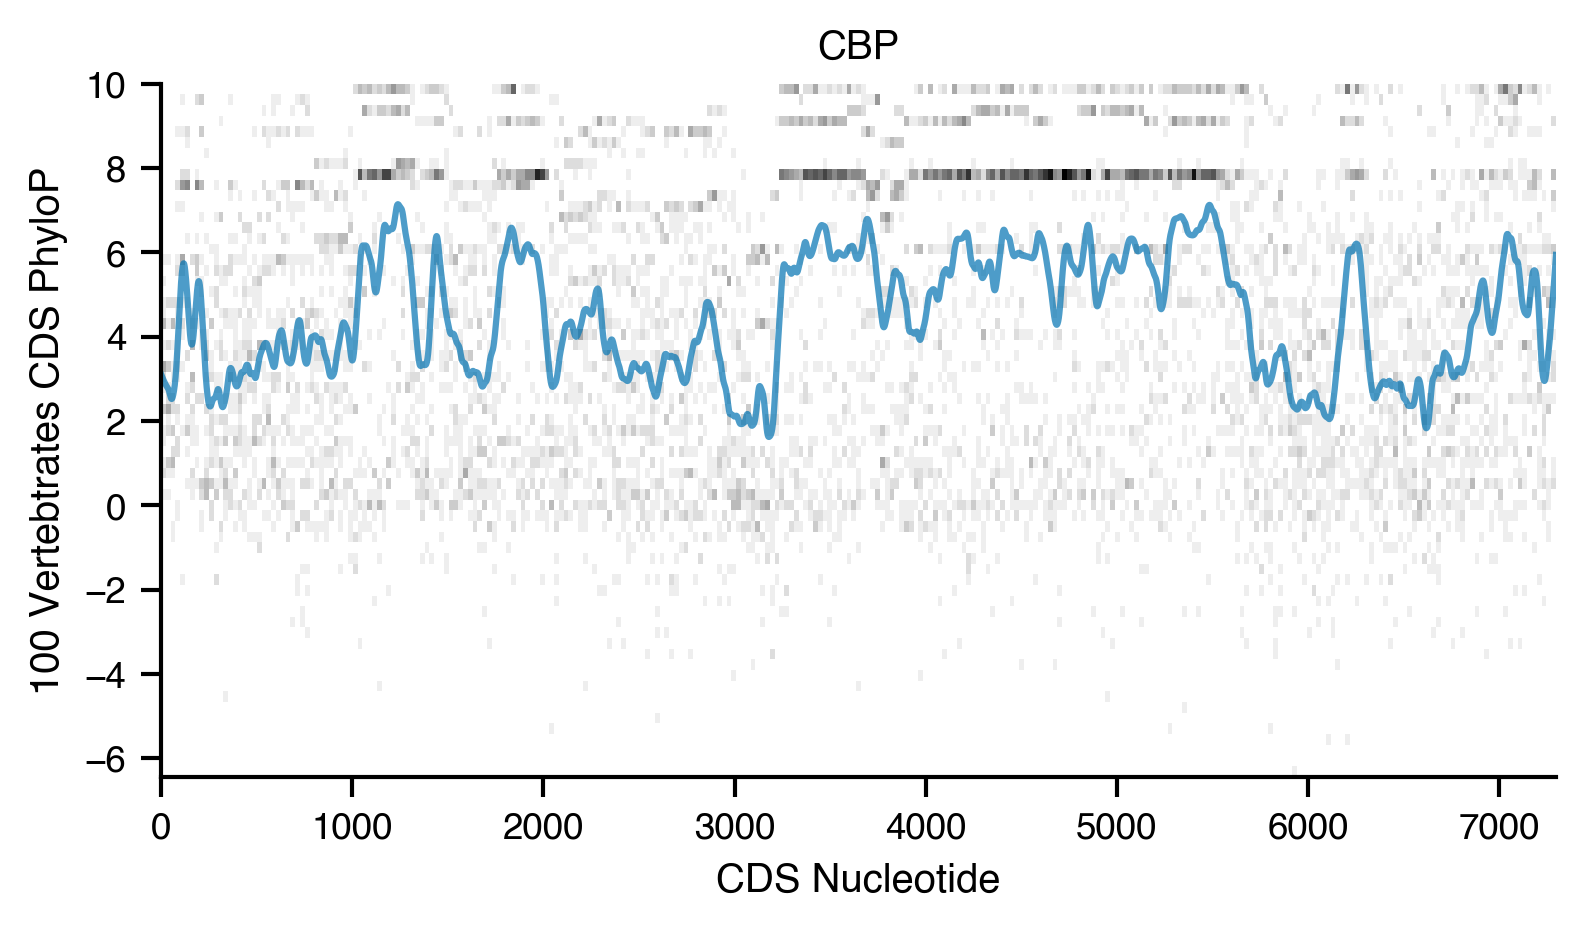

In [11]:
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_context('paper')
fig, ax = plt.subplots(figsize = (6,3), dpi = 300)

smoothed = lowess(cbp_verteb_alignment_df['name'], 
                    cbp_verteb_alignment_df["cds_nt"], 
                    frac=0.01)  # Adjust frac for smoothness
smoothed_df = pd.DataFrame(smoothed, columns=["cds_nt", 'smoothed'])

cutoff_y = np.percentile(cbp_verteb_alignment_df['name'], 1)
y_range = max(cbp_verteb_alignment_df["name"]) + 1 - cutoff_y

h = ax.hist2d(data=cbp_verteb_alignment_df, 
                x="cds_nt", 
                y='name', cmap  = 'binary', bins = [len(smoothed_df) // 25, int(y_range) * 5], alpha =1)
#fig.colorbar(h[3], ax=ax)
ax.set_ylabel(f"100 Vertebtrates CDS PhyloP")

sns.lineplot(data=smoothed_df, x="cds_nt", y='smoothed', color=sns.color_palette('colorblind')[0], ax = ax, lw = 1.5, alpha = 0.7)   
sns.despine()
plt.title("CBP")
plt.xlabel("CDS Nucleotide")

## CITED 2 100 Vertebrates

In [12]:
# Define the paths to your BED files
#cited2_file = "../data/cited2.bed"
#cited2_file = "../soto_analysis/outputs/mutations/domains_bed_format/A0A087WUV0"
#verteb_alignment = "../soto_analysis/raw_files/zoonomia_all_TF_cds.bed"

cited2_file = "../data/cited2.bed"
verteb_alignment = "../soto_analysis/raw_files/100_verteb_cited2_cbp.bed"


# Create BedTool objects
bed_a = pybedtools.BedTool(cited2_file)
bed_b = pybedtools.BedTool(verteb_alignment)

# Perform the cited2_verteb_alignment
cited2_verteb_alignment = bed_b.intersect(bed_a)

# Print the result
cited2_verteb_alignment_df = cited2_verteb_alignment.saveas().to_dataframe()
cited2_verteb_alignment_df

,chrom,start,end,name
0,6,139373132,139373133,3.528290
1,6,139373133,139373134,8.552090
2,6,139373134,139373135,0.777165
3,6,139373135,139373136,7.236330
4,6,139373136,139373137,8.552090
...,...,...,...,...
807,6,139373939,139373940,5.442120
808,6,139373940,139373941,6.638260
809,6,139373941,139373942,5.083280
810,6,139373942,139373943,6.159800


In [13]:
# CITED2 is on the negative strand so sorting highest to lowest
cited2_verteb_alignment_df = cited2_verteb_alignment_df.sort_values(by = "start", ascending = False)
cited2_verteb_alignment_df["cds_nt"] = np.arange(len(cited2_verteb_alignment_df))
cited2_verteb_alignment_df

,chrom,start,end,name,cds_nt
811,6,139373943,139373944,5.083280,0
810,6,139373942,139373943,6.159800,1
809,6,139373941,139373942,5.083280,2
808,6,139373940,139373941,6.638260,3
807,6,139373939,139373940,5.442120,4
...,...,...,...,...,...
4,6,139373136,139373137,8.552090,807
3,6,139373135,139373136,7.236330,808
2,6,139373134,139373135,0.777165,809
1,6,139373133,139373134,8.552090,810


Text(0.5, 0, 'CDS Nucleotide')

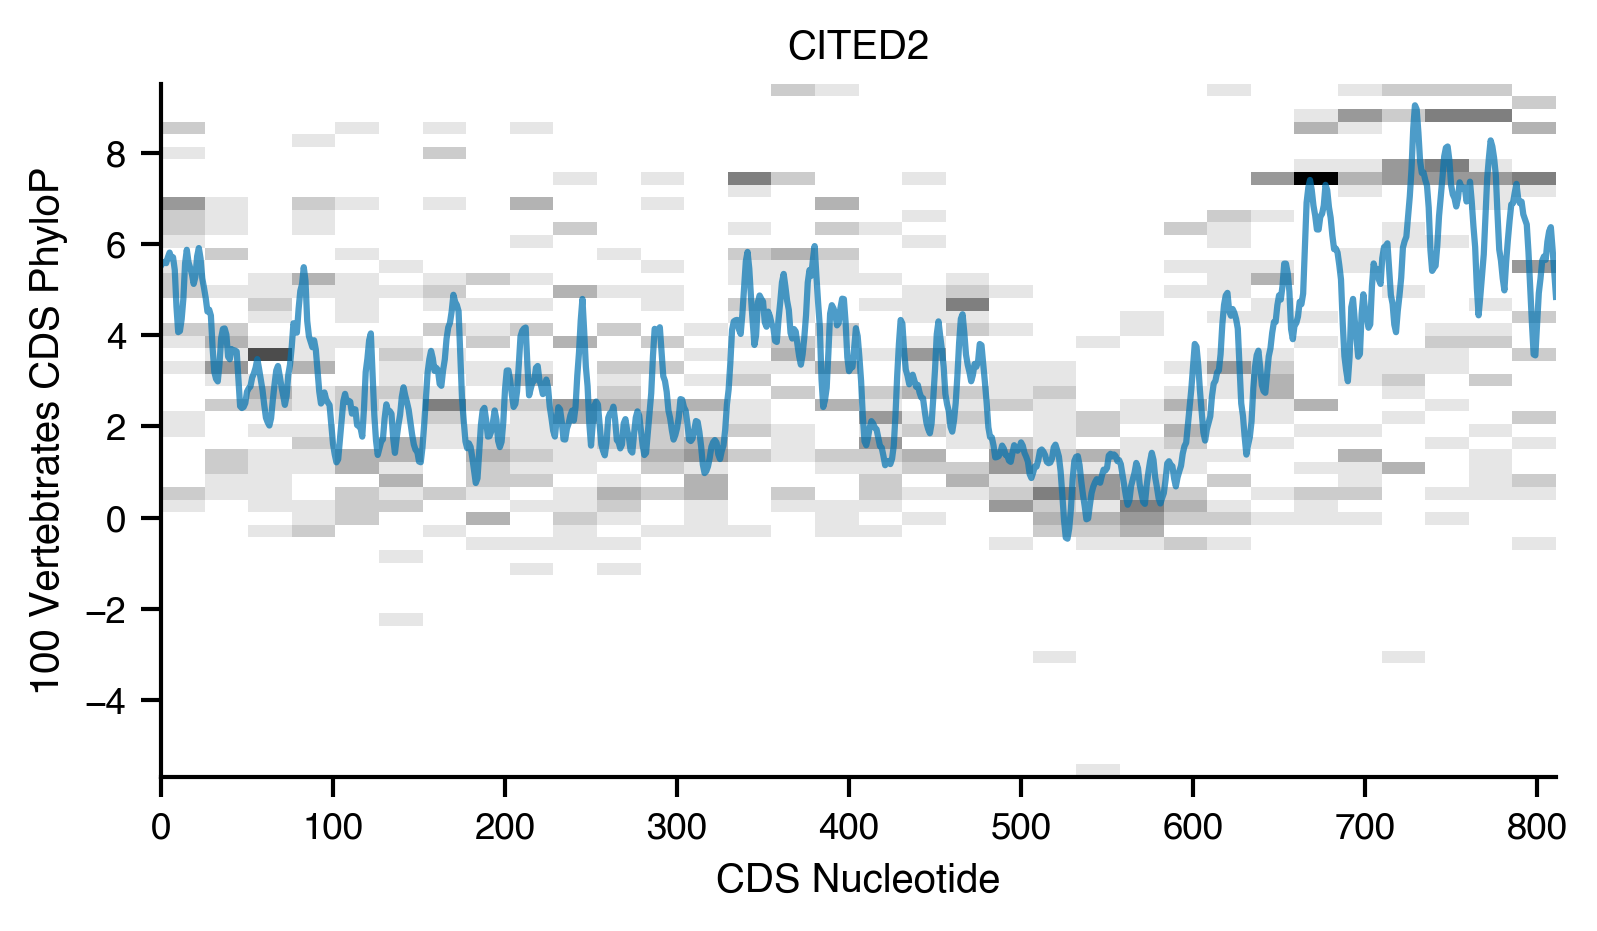

In [14]:
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_context('paper')
fig, ax = plt.subplots(figsize = (6,3), dpi = 300)

smoothed = lowess(cited2_verteb_alignment_df['name'], 
                    cited2_verteb_alignment_df["cds_nt"], 
                    frac=0.01)  # Adjust frac for smoothness
smoothed_df = pd.DataFrame(smoothed, columns=["cds_nt", 'smoothed'])

cutoff_y = np.percentile(cited2_verteb_alignment_df['name'], 1)
y_range = max(cited2_verteb_alignment_df["name"]) + 1 - cutoff_y

h = ax.hist2d(data=cited2_verteb_alignment_df, 
                x="cds_nt", 
                y='name', cmap  = 'binary', bins = [len(smoothed_df) // 25, int(y_range) * 5], alpha =1)
#fig.colorbar(h[3], ax=ax)
ax.set_ylabel(f"100 Vertebtrates CDS PhyloP")

sns.lineplot(data=smoothed_df, x="cds_nt", y='smoothed', color=sns.color_palette('colorblind')[0], ax = ax, lw = 1.5, alpha = 0.7)   
sns.despine()
plt.title("CITED2")
plt.xlabel("CDS Nucleotide")

# Versus all activator TFs 100 vertebrates

In [19]:
import glob

ad_phylo_P = []

ENSTs = glob.glob("../soto_analysis/outputs/mutations/domains_100_verteb_all_TF_cds/*")
for ENST in ENSTs:
    df = pd.read_csv(ENST, sep = "\t", header = None)
    ad_phylo_P.append(df)

ad_phylo_P = pd.concat(ad_phylo_P)
ad_phylo_P = ad_phylo_P.rename(columns = {7: "ENST", 16: "PhyloP"})
dbd_phylo_P = ad_phylo_P[ad_phylo_P[3] == "DBD"]
ad_phylo_P = ad_phylo_P[ad_phylo_P[3] == "AD"]
ad_phylo_P

,0,1,2,3,4,5,6,ENST,8,9,10,11,12,13,14,15,PhyloP
412,6,53128858,53128859,AD,NaN,.,-1,ENST00000259803,6,53128858,53128859,ENST00000259803,-1,6,53128858,53128859,2.090440
413,6,53128857,53128858,AD,NaN,.,-1,ENST00000259803,6,53128857,53128858,ENST00000259803,-1,6,53128857,53128858,1.471040
414,6,53128856,53128857,AD,NaN,.,-1,ENST00000259803,6,53128856,53128857,ENST00000259803,-1,6,53128856,53128857,1.006490
415,6,53128855,53128856,AD,NaN,.,-1,ENST00000259803,6,53128855,53128856,ENST00000259803,-1,6,53128855,53128856,1.703320
416,6,53128854,53128855,AD,NaN,.,-1,ENST00000259803,6,53128854,53128855,ENST00000259803,-1,6,53128854,53128855,-0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,19,15373917,15373918,AD,NaN,.,-1,ENST00000269701,19,15373917,15373918,ENST00000269701,-1,19,15373917,15373918,1.217070
2296,19,15373916,15373917,AD,NaN,.,-1,ENST00000269701,19,15373916,15373917,ENST00000269701,-1,19,15373916,15373917,-0.733197
2297,19,15373915,15373916,AD,NaN,.,-1,ENST00000269701,19,15373915,15373916,ENST00000269701,-1,19,15373915,15373916,2.346170
2298,19,15373914,15373915,AD,NaN,.,-1,ENST00000269701,19,15373914,15373915,ENST00000269701,-1,19,15373914,15373915,0.909134


In [53]:
activator_cds_phylop = []
non_activator_cds_phylop = []

cds_paths = glob.glob("../soto_analysis/outputs/mutations/cds_100_verteb_all_TF_cds/*")

for path in cds_paths:
    ENST = path.split("/")[-1].split(".bed")[0]
    if ENST in set(ad_phylo_P["ENST"]):
        df = pd.read_csv(path, sep = "\t", header = None)
        activator_cds_phylop.append(df)
    else:
        df = pd.read_csv(path, sep = "\t", header = None)
        non_activator_cds_phylop.append(df)

activator_cds_phylop = pd.concat(activator_cds_phylop)
activator_cds_phylop = activator_cds_phylop.rename(columns = {3: "ENST", 8: "PhyloP"})
display(activator_cds_phylop)

non_activator_cds_phylop = pd.concat(non_activator_cds_phylop)
non_activator_cds_phylop = non_activator_cds_phylop.rename(columns = {3: "ENST", 8: "PhyloP"})
display(non_activator_cds_phylop)

,0,1,2,ENST,4,5,6,7,PhyloP
0,6,53128206,53128207,ENST00000259803,-1,6,53128206,53128207,1.030160
1,6,53128207,53128208,ENST00000259803,-1,6,53128207,53128208,3.733460
2,6,53128208,53128209,ENST00000259803,-1,6,53128208,53128209,0.309276
3,6,53128209,53128210,ENST00000259803,-1,6,53128209,53128210,2.021370
4,6,53128210,53128211,ENST00000259803,-1,6,53128210,53128211,0.309276
...,...,...,...,...,...,...,...,...,...
2060,19,15379726,15379727,ENST00000269701,-1,19,15379726,15379727,2.350910
2061,19,15379727,15379728,ENST00000269701,-1,19,15379727,15379728,2.350910
2062,19,15379728,15379729,ENST00000269701,-1,19,15379728,15379729,3.741970
2063,19,15379729,15379730,ENST00000269701,-1,19,15379729,15379730,2.930520


,0,1,2,ENST,4,5,6,7,PhyloP
0,2,27149134,27149135,ENST00000296096,1,2,27149134,27149135,2.594350
1,2,27149135,27149136,ENST00000296096,1,2,27149135,27149136,1.305030
2,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,-0.060134
3,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,2.594350
4,2,27149138,27149139,ENST00000296096,1,2,27149138,27149139,-0.211819
...,...,...,...,...,...,...,...,...,...
3842,16,49822680,49822681,ENST00000561648,-1,16,49822680,49822681,-1.623430
3843,16,49822681,49822682,ENST00000561648,-1,16,49822681,49822682,-0.067441
3844,16,49822682,49822683,ENST00000561648,-1,16,49822682,49822683,-0.660197
3845,16,49822683,49822684,ENST00000561648,-1,16,49822683,49822684,-1.030670


In [57]:
cds_phylo_P_average_per_activator_TF = activator_cds_phylop[["ENST", "PhyloP"]].groupby("ENST").mean().reset_index()
display(cds_phylo_P_average_per_activator_TF)

,ENST,PhyloP
0,ENST00000008391,5.788008
1,ENST00000056233,1.241109
2,ENST00000078445,1.597000
3,ENST00000162391,3.257468
4,ENST00000177694,2.329711
...,...,...
425,ENST00000696851,3.742760
426,ENST00000698141,3.828075
427,ENST00000698192,1.619667
428,ENST00000700044,4.461075


In [59]:
cds_phylo_P_average_per_non_activator_TF = non_activator_cds_phylop[["ENST", "PhyloP"]].groupby("ENST").mean().reset_index()
cds_phylo_P_average_per_non_activator_TF

,ENST,PhyloP
0,ENST00000006015,4.691037
1,ENST00000007699,2.322970
2,ENST00000012134,3.161679
3,ENST00000020945,4.945355
4,ENST00000040584,4.866290
...,...,...
1123,ENST00000699333,-0.309321
1124,ENST00000703967,5.111611
1125,ENST00000704756,4.406067
1126,ENST00000706170,0.319686


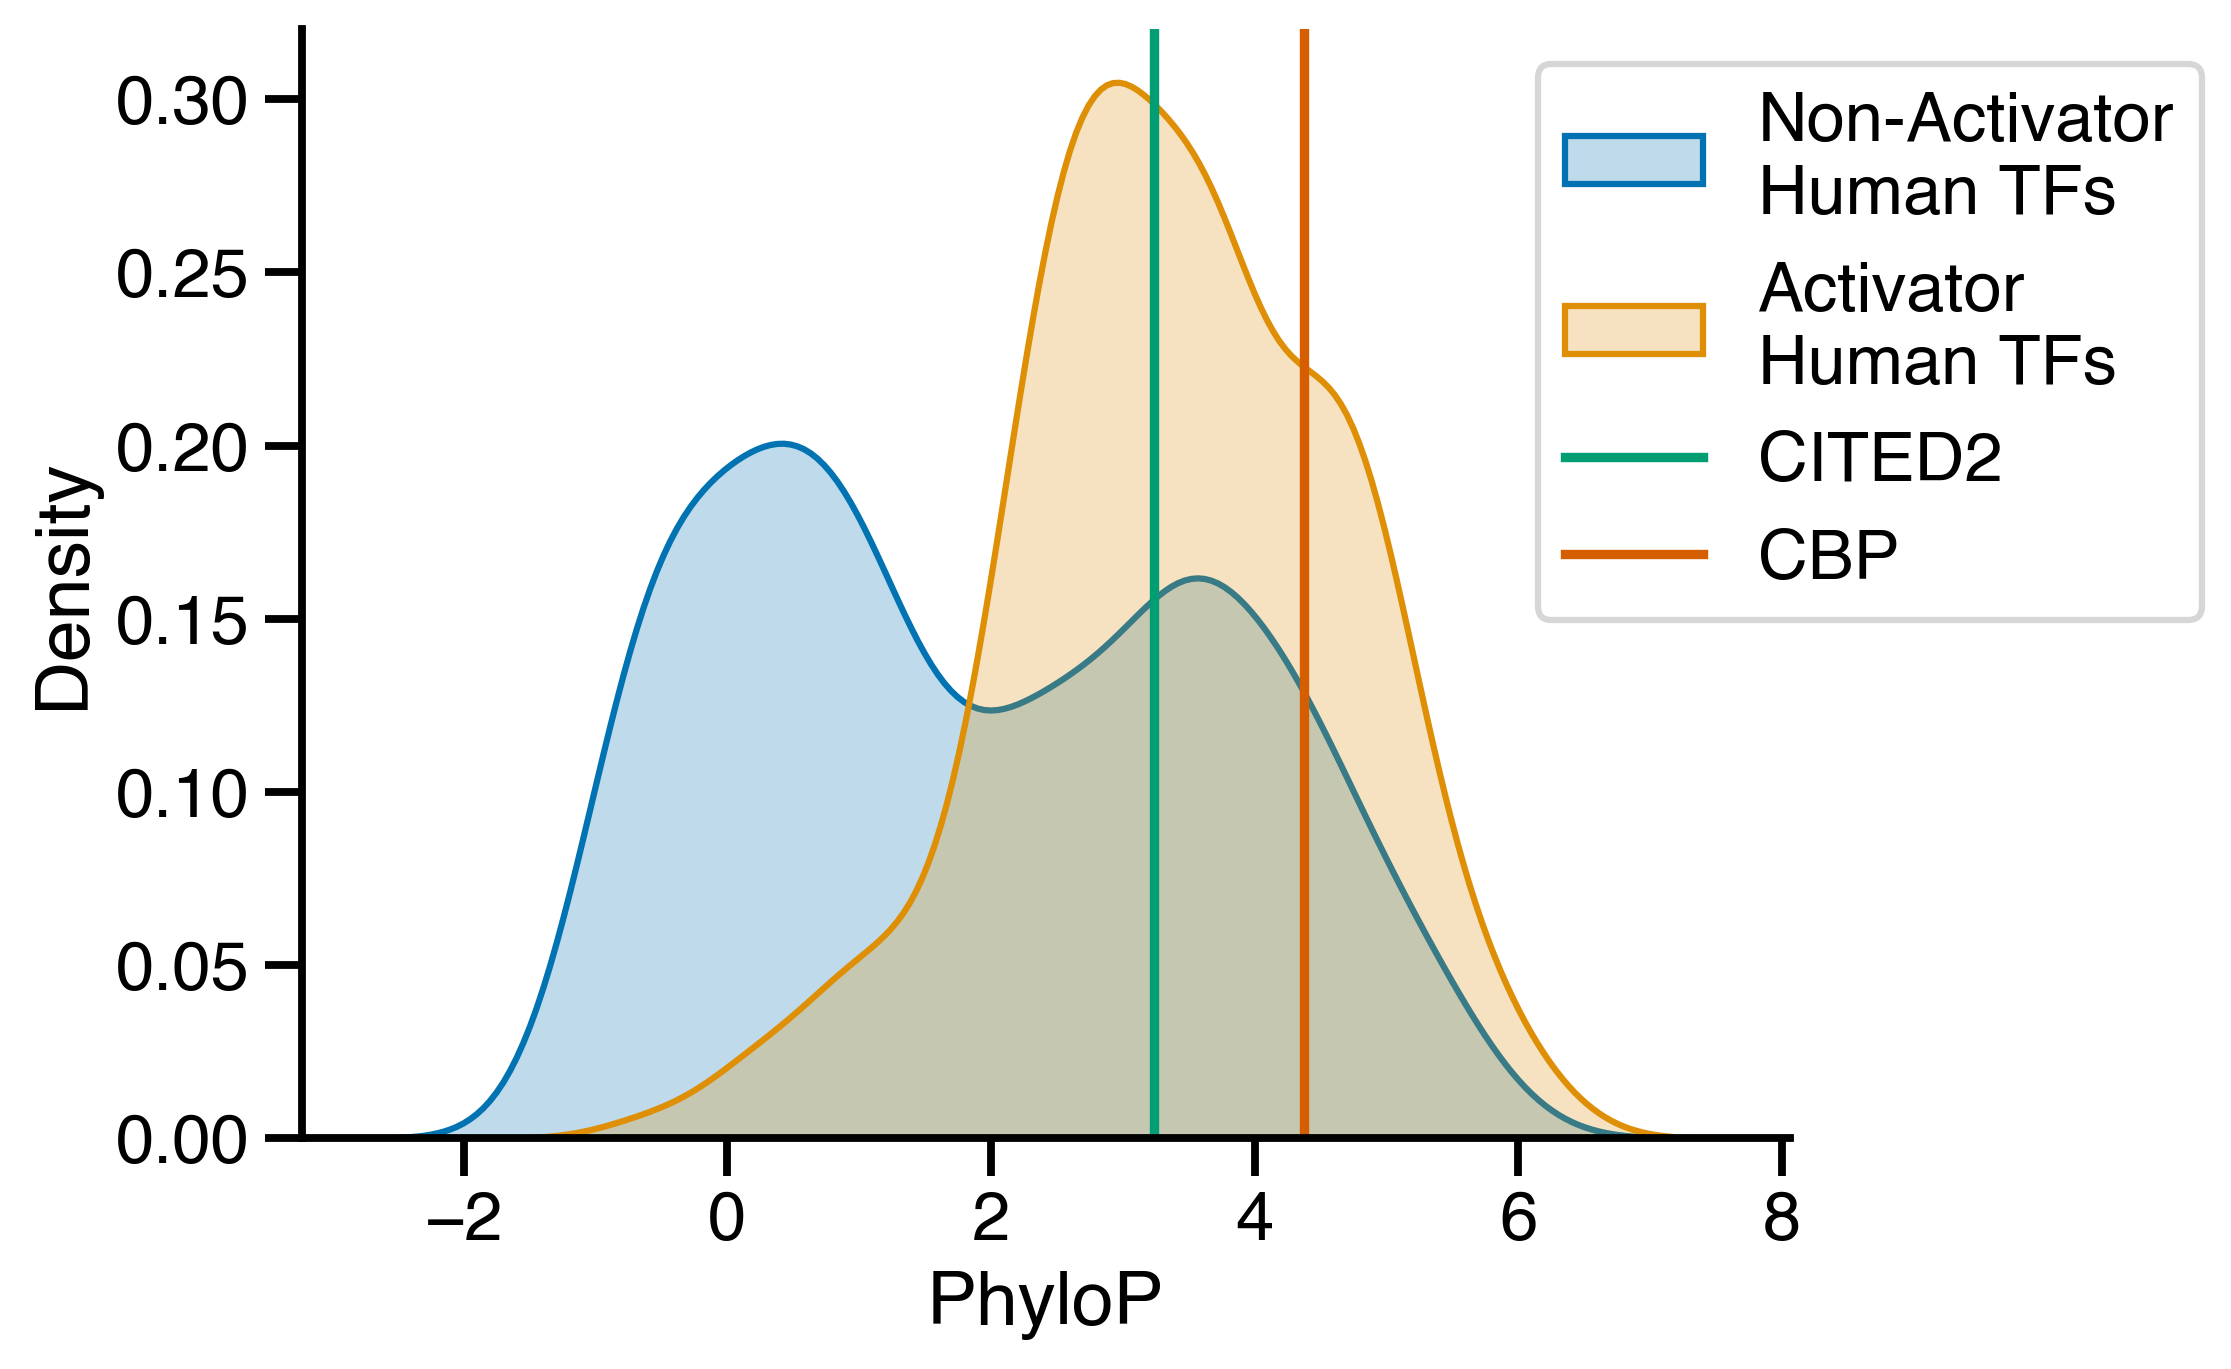

In [78]:
sns.set_context('talk')
plt.figure(dpi = 300)
palette = sns.color_palette('colorblind', n_colors=4)

sns.kdeplot(cds_phylo_P_average_per_non_activator_TF["PhyloP"], label = "Non-Activator\nHuman TFs", color=palette[0], fill = True)
sns.kdeplot(cds_phylo_P_average_per_activator_TF["PhyloP"], label = "Activator\nHuman TFs", color=palette[1], fill = True)
plt.axvline(np.mean(cited2_verteb_alignment_df["name"]), label = "CITED2", color=palette[2])
plt.axvline(np.mean(cbp_verteb_alignment_df["name"]), label = "CBP", color=palette[3])
plt.legend(bbox_to_anchor = (1.3,1), loc = "upper right")
sns.despine()

In [91]:
cds_phylo_P_average_per_activator_TF["group"] = "activator"
cds_phylo_P_average_per_non_activator_TF["group"] = "non-activator"
all_cds_phyloP_average_per_TF = pd.concat([cds_phylo_P_average_per_non_activator_TF, cds_phylo_P_average_per_activator_TF], ignore_index=True)
all_cds_phyloP_average_per_TF

,ENST,PhyloP,group
0,ENST00000006015,4.691037,non-activator
1,ENST00000007699,2.322970,non-activator
2,ENST00000012134,3.161679,non-activator
3,ENST00000020945,4.945355,non-activator
4,ENST00000040584,4.866290,non-activator
...,...,...,...
1553,ENST00000696851,3.742760,activator
1554,ENST00000698141,3.828075,activator
1555,ENST00000698192,1.619667,activator
1556,ENST00000700044,4.461075,activator


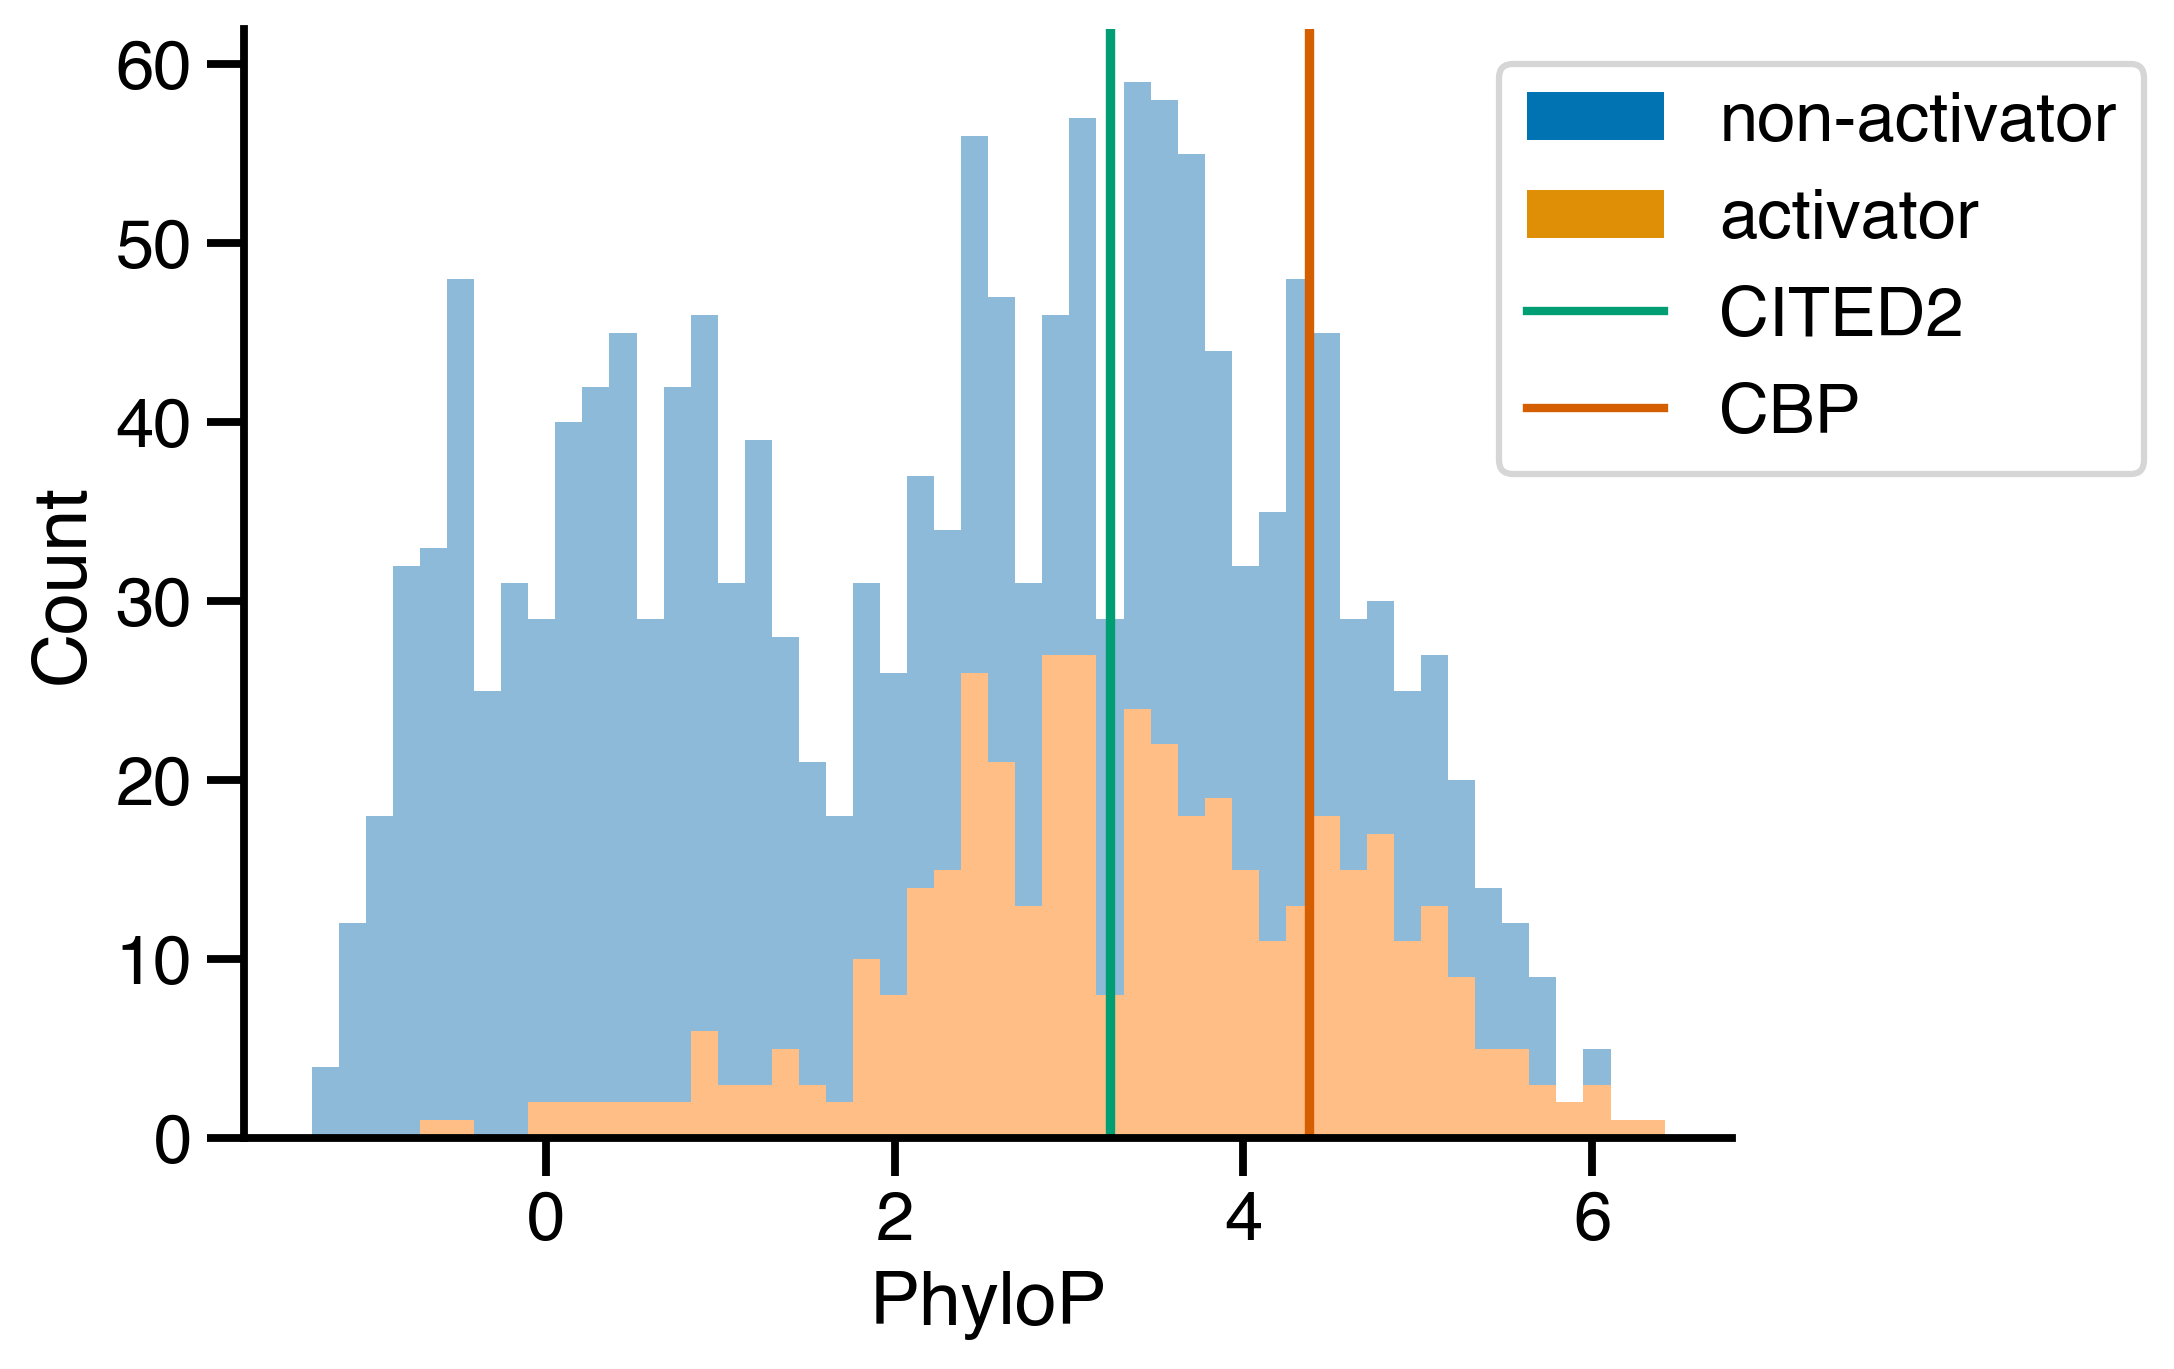

In [101]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


palette = sns.color_palette('colorblind', n_colors=4)

# --- Plotting ---
plt.figure()

# Vertical lines
plt.axvline(np.mean(cited2_verteb_alignment_df["name"]), 
            label="CITED2",
            color=palette[2])
plt.axvline(np.mean(cbp_verteb_alignment_df["name"]), 
            label="CBP",
            color=palette[3])

# Histogram with hue
sns.histplot(data=all_cds_phyloP_average_per_TF,
             x="PhyloP",
             hue="group",
             multiple='stack', bins = 50, alpha = 0.5, edgecolor = 'none')

sns.despine()

# --- Build legend handles manually ---

# 1. Get hue categories
groups = all_cds_phyloP_average_per_TF["group"].unique()

# 2. Assign colors to hue groups (first part of palette)
hue_colors = palette[:len(groups)]

# 3. Build handles for histogram groups
hist_handles = [Patch(facecolor=hue_colors[i], label=groups[i]) 
                for i in range(len(groups))]

# 4. Build handles for axvline markers
line_handles = [
    Line2D([0], [0], color=palette[2], lw=2, label="CITED2"),
    Line2D([0], [0], color=palette[3], lw=2, label="CBP")
]

# 5. Combine and show legend
plt.legend(handles=hist_handles + line_handles,
           bbox_to_anchor=(1.3,1),
           loc="upper right")

plt.show()